# Estatística Descritiva

## Estatística Descritiva - Univariada

### Histogramas - Número de intervalos

- As variáveis quantitativas contínuas representam grandezas mensuráveis que assumem valores dentro de um intervalo real, como altura, peso ou tempo. Por conta dessa continuidade, os valores são infinitos dentro de um intervalo, o que dificulta a contagem e a análise individual de cada valor observado.

- Para facilitar a interpretação dos dados, é comum agrupar os valores em faixas ou classes, definindo intervalos que agrupem os dados em blocos. Essa divisão permite observar a distribuição geral dos dados sem a necessidade de analisar cada ponto separadamente.

- O número e o tamanho das classes devem ser escolhidos com cuidado. Se criarmos poucas classes, podemos perder informações importantes. Por outro lado, muitas classes tornam o gráfico ou a tabela pouco informativos. Embora os intervalos entre as classes possam variar, na prática adota-se um tamanho de intervalo constante por questões de simplicidade e clareza na visualização.

Abaixo está a base de dados contendo 30 valores de altura. Esses dados foram gerados aleatoriamente dentro do intervalo de 1,0m a 2,1m e servirão como referência para as análises estatísticas a seguir.

In [1]:
import pandas as pd

DADOS = "./dados/alturas.csv"
df = pd.read_csv(DADOS)
df.head()

,altura
0,1.41
1,2.05
2,1.81
3,1.66
4,1.17


In [2]:
# Apenas para ter uma ideia dos dados dessa base
df.describe()

,altura
count,30.000000
mean,1.482000
std,0.312105
min,1.020000
25%,1.205000
50%,1.445000
75%,1.667500
max,2.070000


In [3]:
# Saber quantos desses dados de altura se repetem
df.value_counts()

altura
1.17      2
1.20      2
1.32      2
1.66      2
1.05      1
1.02      1
1.06      1
1.22      1
1.23      1
1.15      1
1.33      1
1.40      1
1.48      1
1.41      1
1.50      1
1.57      1
1.58      1
1.65      1
1.67      1
1.78      1
1.81      1
1.86      1
1.92      1
1.95      1
2.05      1
2.07      1
Name: count, dtype: int64

- Ao construir tabelas ou histogramas para representar dados contínuos, um ponto crucial é decidir quantas classes utilizar. Diversos métodos estatísticos foram desenvolvidos para estimar automaticamente a quantidade ideal de intervalos, levando em consideração o tamanho da amostra, a variabilidade dos dados e até mesmo a forma da distribuição. Abaixo estão os principais critérios utilizados:

**k** = quantas faixas você terá.

**h** = qual o tamanho de cada faixa.

Link para documentação: https://numpy.org/doc/2.1/reference/generated/numpy.histogram_bin_edges.html

#### Auto

- É um método adaptativo que escolhe entre as regras de Sturges e de Freedman–Diaconis (FD), dependendo do tamanho da amostra. Para conjuntos pequenos, tende a usar Sturges; para conjuntos maiores, escolhe FD. É um bom ponto de partida geral.

#### Freedman–Diaconis (fd)

- Considera a dispersão dos dados por meio do intervalo interquartil (IQR) e é especialmente útil quando há presença de outliers. Quanto maior a dispersão, maior será a largura dos intervalos. Sua fórmula é:

$$ h = 2 \cdot \frac{IQR}{n^{1/3}} $$

#### Scott

- Baseia-se no desvio padrão dos dados e também leva em conta o tamanho da amostra. Funciona bem em distribuições simétricas e grandes amostras, mas é sensível a valores extremos. Sua fórmula é:

$$ h = \sigma \cdot \sqrt[3]{\frac{24\sqrt{\pi}}{n}} $$

#### Rice

- Usa apenas o tamanho da amostra e ignora qualquer medida de dispersão. Por isso, tende a superestimar o número de classes, especialmente em conjuntos com baixa variabilidade. Sua fórmula é:

$$ k = 2 \cdot n^{1/3} $$

#### Sturges

- Uma das regras mais clássicas, baseada apenas na quantidade de observações. Assume que os dados seguem uma distribuição normal, podendo subestimar o número de classes em conjuntos não normais. Fórmula:

$$ k = 1 + \log_2(n) $$

#### Doane

- Aprimora a fórmula de Sturges ao considerar a assimetria (skewness) da distribuição. Produz estimativas melhores para conjuntos que não seguem a normalidade. Fórmula:

$$ k = 1 + \log_2(n) + \log_2 \left(1 + \frac{|g_1|}{\sigma_{g_1}}\right) $$

$$ g_1 = \text{mean} \left[ \left(\frac{x - \mu}{\sigma}\right)^3 \right] $$

$$ \sigma_{g_1} = \sqrt{\frac{6(n - 2)}{(n + 1)(n + 3)}} $$

#### Stone

- Utiliza validação cruzada para minimizar o erro quadrático médio entre os dados e sua distribuição por classes. Embora mais preciso, é computacionalmente mais custoso. Pode ser visto como uma extensão da regra de Scott.

#### Sqrt

- Muito utilizado em ferramentas como o Excel por sua facilidade e agilidade, sendo um método mais simples e rápido, baseado apenas na raiz quadrada do tamanho da amostra:

$$ k = \sqrt{n} $$

- Para o conjunto de dados de alturas que utilizaremos como exemplo, adotaremos a regra de Sturges como critério para definir a quantidade de classes. Essa abordagem é adequada para amostras pequenas e fornece uma estimativa simples e prática do número de intervalos a serem utilizados.

- O método `np.histogram_bin_edges` é muito mais utilizado, pois basta apenas colocar o nome do método que deseja utilizar.

In [4]:
import numpy as np

# Calcular a quantidade de faixas usando a fórmula
k = 1 + np.log2(df.shape[0])
print(f'k antes de arredondar: {k}') # nota-se que o valor é dado em float, então é necessário arredondar para cima

k = np.ceil(k)
print(f'k depois de arredondar: {k}')

# Calcular a quantidade de faixas usando o método histogram_bin_edges
bins = np.histogram_bin_edges(df['altura'], bins='sturges')
bins

k antes de arredondar: 5.906890595608519
k depois de arredondar: 6.0


array([1.02 , 1.195, 1.37 , 1.545, 1.72 , 1.895, 2.07 ])

In [5]:
# Ver a quantidade de dados por intervalo
df['altura'].value_counts(bins=bins).sort_index()

(1.0190000000000001, 1.195]    6
(1.195, 1.37]                  7
(1.37, 1.545]                  4
(1.545, 1.72]                  6
(1.72, 1.895]                  3
(1.895, 2.07]                  4
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

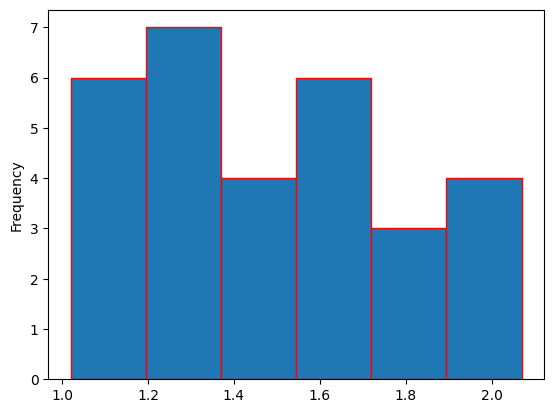

In [6]:
# Plotar um histograma com esses dados
df['altura'].plot.hist(bins=int(k), edgecolor='red')

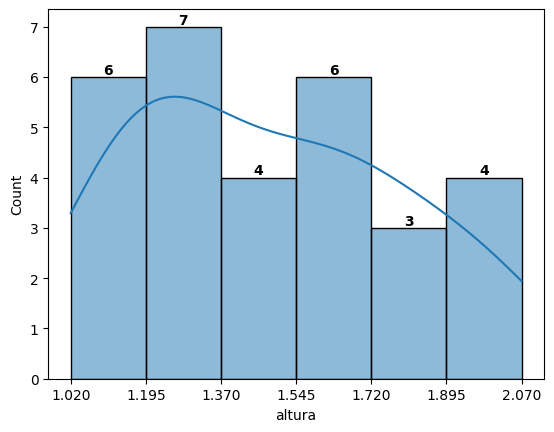

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

h = sns.histplot(data=df, x='altura', bins=bins, kde=True)

for barra in h.containers:
    h.bar_label(barra, color='black', fontweight='bold', fontsize=10)

h.set_xticks(bins)

plt.show()

### Medidas de Posição - Tendência Central

- As medidas de posição são ferramentas estatísticas utilizadas para indicar a localização dos dados ao longo de uma escala de valores. Elas ajudam a entender onde os dados estão concentrados ou como estão distribuídos. Podem ser classificadas em dois grandes grupos:

    - **Medidas de tendência central:** como a média, a mediana e a moda, que representam valores centrais do conjunto de dados.

    - **Medidas separatrizes:** como quartis, decis e percentis, que dividem os dados em partes iguais, permitindo uma análise mais detalhada da distribuição.

Para tornar a explicação mais clara, será utilizada uma nova base de dados que também aborda medidas de altura, desta vez referentes a estudantes do ensino médio.

In [8]:
import pandas as pd

BASE = './dados/alturas_estudantes.csv'
df = pd.read_csv(BASE)
df.head()

,altura
0,1.72
1,1.67
2,1.73
3,1.80
4,1.66


In [9]:
df.value_counts()

altura
1.64      5
1.66      4
1.80      2
1.72      2
1.57      2
1.69      2
1.71      2
1.53      1
1.54      1
1.59      1
1.67      1
1.63      1
1.60      1
1.61      1
1.70      1
1.73      1
1.74      1
1.81      1
Name: count, dtype: int64

#### Moda

- A moda é a medida de tendência central que representa o valor mais frequente em um conjunto de dados. Ela é especialmente útil quando se deseja identificar repetições ou padrões em séries numéricas ou categorias.

- Diferente da média e da mediana, a moda pode ser usada para variáveis qualitativas, como cores, marcas ou categorias, já que depende apenas da frequência dos valores.

    - Em dados não agrupados, a moda é simplesmente o valor que mais aparece.

    - Para dados agrupados em classes contínuas, existem fórmulas específicas para estimar a moda, como as propostas por King e Czuber. Essas abordagens ajudam a localizar o ponto mais concentrado da distribuição dentro de um intervalo.

In [10]:
# Calculando a moda
df['altura'].mode()

0    1.64
Name: altura, dtype: float64

#### Média Aritmética

- A média aritmética é uma das medidas mais utilizadas para representar o valor central de um conjunto de dados. Quando calculada para uma população, ela é indicada pela letra grega *μ*; já quando se refere a uma amostra, utiliza-se o símbolo $\bar{X}$.

- O cálculo da média pode variar conforme o tipo de dado analisado, se os dados são discretos ou contínuos, agrupados ou não. Além disso, é possível aplicar pesos diferentes às observações, originando a média ponderada. Quando todos os valores têm o mesmo peso, temos a média aritmética simples.

$$ \bar{X} = \frac{\sum\limits_{i=1}^{n} X_{i}}{n} $$

- Em que:

    - $n$ é o número total de observações,  
    
    - $X_i$ representa o valor de cada uma delas.

In [11]:
# Calculando a média
df['altura'].mean()

np.float64(1.6656666666666666)

#### Mediana

- A mediana é uma medida de tendência central que indica o valor central de um conjunto de dados ordenados. Ela divide os dados em duas metades: 50% dos valores ficam abaixo da mediana e os outros 50% ficam acima. Para que o cálculo seja feito corretamente, os dados precisam estar organizados em ordem crescente.

- Quando lidamos com dados não agrupados, a forma de calcular a mediana depende da quantidade total de elementos:

    - Se o número de dados for ímpar, a mediana será o valor que estiver exatamente no meio da lista.

    - Se for par, a mediana será a média entre os dois valores centrais.

$$
Md(X) = \left\{ \begin{array}{ll}
X_{\left(\frac{n+1}{2}\right)} & \text{se } n \text{ ímpar} \\
\frac{X_{\left(\frac{n}{2}\right)} + X_{\left(\frac{n}{2}+1\right)}}{2} & \text{se } n \text{ par}
\end{array} \right.
$$

In [12]:
# Calcular a mediana
df['altura'].median()

np.float64(1.66)

### Medidas de Posição - Medidas Separatrizes

- Em muitos casos, usar apenas a média, a mediana ou a moda não é o bastante para representar adequadamente um conjunto de dados. Isso porque esses valores centrais podem ser influenciados por extremos ou não mostrar como os dados estão distribuídos.

- As medidas separatrizes surgem justamente para complementar essa análise. Elas têm a função de dividir os dados ordenados em partes iguais, ajudando a entender melhor como os valores estão espalhados ao longo do conjunto.

- Entre os principais tipos de separatrizes estão os quartis, que dividem os dados em quatro partes; os decis, que os separam em dez partes; e os percentis, que os fracionam em cem partes. Esses valores são todos casos específicos de uma mesma ideia: os quantis.

#### Quartis

- Os quartis são medidas que dividem os dados ordenados em quatro partes iguais, cada uma contendo 25% das observações. Eles ajudam a entender como os valores estão distribuídos ao longo do conjunto.

    - O primeiro quartil (Q1) corresponde ao percentil 25. Isso significa que 25% dos dados estão abaixo de Q1 e os outros 75% estão acima dele.

    - O segundo quartil (Q2) é equivalente à mediana. Ele separa o conjunto ao meio, indicando que 50% dos dados estão abaixo e 50% acima desse valor.

    - O terceiro quartil (Q3) representa o percentil 75. Ou seja, 75% dos dados estão abaixo de Q3 e os 25% restantes estão acima.

- No exemplo abaixo, é possível usar o `.quantile([])` para mostrar os quartis, basta apenas colocar os intervalos dentro das `[]`

In [13]:
# Mostrar os quartis da coluna altura
df['altura'].quantile([0.25, 0.50, 0.75])

0.25    1.6325
0.50    1.6600
0.75    1.7100
Name: altura, dtype: float64

- Um outro exemplo seria criar outras 2 colunas para analisar em qual dos quartis cada dado de altura está.

In [14]:
df = df['altura'].sort_values().reset_index(drop=True).to_frame()

df["quartis_"] = pd.qcut(df["altura"], q=4, precision=2)

df["quartis"] = pd.qcut(
    df["altura"], 
    q=4,
    labels=["0-25%", "25-50%", "50-75%", "75-100%"]
)

df

,altura,quartis_,quartis
0,1.53,"(1.52, 1.63]",0-25%
1,1.54,"(1.52, 1.63]",0-25%
2,1.57,"(1.52, 1.63]",0-25%
3,1.57,"(1.52, 1.63]",0-25%
4,1.59,"(1.52, 1.63]",0-25%
5,1.60,"(1.52, 1.63]",0-25%
6,1.61,"(1.52, 1.63]",0-25%
7,1.63,"(1.52, 1.63]",0-25%
8,1.64,"(1.63, 1.66]",25-50%
9,1.64,"(1.63, 1.66]",25-50%


#### Decis

- Os decis são medidas estatísticas que dividem um conjunto de dados organizados em ordem crescente em dez partes iguais, cada uma contendo 10% dos valores.

- A interpretação dos decis segue a mesma lógica dos quartis. Por exemplo:

    - O primeiro decil (D₁), também conhecido como 10º percentil, indica que 10% dos dados estão abaixo de D₁, enquanto os 90% restantes estão acima desse valor.

- No exemplo abaixo, é utilizado o `np.arange(0, 1.1, 0.1)` para gerar uma sequência de valores de 0 até 1, com passo de 0.1. Isso permite calcular os decis, já que divide o intervalo em 10 partes iguais

In [15]:
# Mostrar os decis da coluna altura
df['altura'].quantile(np.arange(0, 1.1, 0.1))

0.0    1.530
0.1    1.570
0.2    1.608
0.3    1.640
0.4    1.640
0.5    1.660
0.6    1.678
0.7    1.703
0.8    1.720
0.9    1.746
1.0    1.810
Name: altura, dtype: float64

#### Percentis

- Os percentis são medidas que fracionam um conjunto de dados ordenados em cem partes iguais.

- Cada percentil indica a posição relativa de um valor dentro do conjunto. Por exemplo:

    - O 1º percentil mostra que 1% dos dados estão abaixo daquele ponto.

    - O 2º percentil indica que 2% dos dados são menores, e assim por diante, até o 99º percentil.

- No exemplo abaixo, é utilizado o `np.arange(0, 1.01, 0.01)` para gerar uma sequência de valores de 0 até 1, com passo de 0.01. Isso permite calcular os percentis, já que divide o intervalo em 100 partes iguais

In [16]:
# Mostrar os percentis da coluna altura
df['altura'].quantile(np.arange(0, 1.01, 0.01))

0.00    1.5300
0.01    1.5329
0.02    1.5358
0.03    1.5387
0.04    1.5448
         ...  
0.96    1.8000
0.97    1.8013
0.98    1.8042
0.99    1.8071
1.00    1.8100
Name: altura, Length: 101, dtype: float64

### Boxplot

- **Boxplot**

    - Boxplot é um gráfico que resume um conjunto de dados em cinco pontos principais: mínimo, primeiro quartil (Q1), mediana (Q2), terceiro quartil (Q3) e máximo.

    - Ele é muito útil para identificar como os dados estão distribuídos, se estão concentrados em alguma faixa, se há valores muito distantes (outliers), e se a distribuição é simétrica ou assimétrica.

- **IQR**
    - Intervalo Interquartil: distância entre Q3 e Q1.

    $$\text{IQR} = Q_3 - Q_1$$

    - Essa medida concentra os 50% centrais e ajuda a detectar outliers.

![BoxPlot](imagens/boxplot.png)

- **Explicando a Imagem**

    - A caixa (box) mostra o intervalo onde estão os 50% do meio dos dados — vai de Q1 até Q3.
Isso representa o IQR.

    - A linha dentro da caixa é a mediana (Q2), que divide o conjunto de dados ao meio.

    - As linhas que saem da caixa, chamadas de bigodes (whiskers), se estendem até os valores mínimos e máximos dentro de um limite aceitável:

        - Limite inferior: Q1 − 1.5 × IQR

        - Limite superior: Q3 + 1.5 × IQR

    - Pontos fora desses limites são chamados de outliers, que são valores muito distantes que podem indicar algo incomum ou erro.

    - O formato do boxplot permite ver a dispersão dos dados e entender se há tendência, concentração ou valores fora do padrão.

- **Forma da distribuição no boxplot**

    - Assimetria à esquerda (cauda à esquerda / skew negativa)

        - A cauda se estende para valores menores.

        - Bigode esquerdo costuma ser mais longo.

        - A mediana (Q2) fica mais perto de Q3 (deslocada para a direita da caixa).

    - Simétrica

        - Caixa “equilibrada”: Q1, Q2 e Q3 ficam aproximadamente equidistantes.

        - Bigodes com comprimentos semelhantes.

        - Média ≈ mediana (sem viés para lados).

    - Assimetria à direita (cauda à direita / skew positiva)

        - A cauda se estende para valores maiores.

        - Bigode direito costuma ser mais longo.

        - A mediana (Q2) fica mais perto de Q1 (deslocada para a esquerda da caixa).

![simetria boxplot](imagens/simetria_boxplot.jpg)

- Abaixo segue um exemplo de uso de boxplot junto a um histograma:

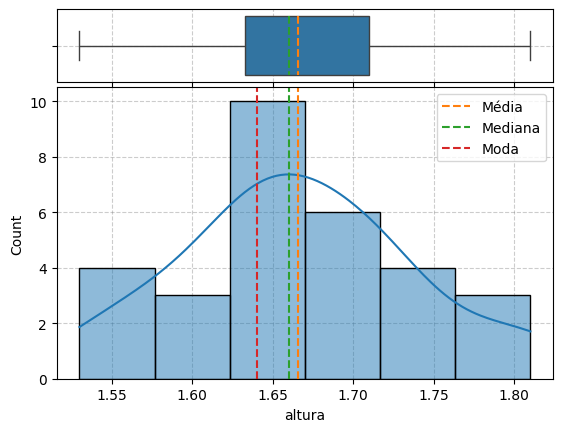

In [ ]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True, # compartilhar o mesmo X
    gridspec_kw={
        "height_ratios": (0.2, 0.8), # porcentagem do tamanho de cada grafico
        "hspace": 0.03 # espaçamento entre cada gráfico
    }
)

sns.boxplot(
    data=df,
    x="altura",
    showmeans=True, # mostrar a média
    meanline=True, # mostrar a linha da média
    meanprops={"color": "C1", "linewidth": 1.5, "linestyle": "--"},
    medianprops={"color": "C2", "linewidth": 1.5, "linestyle": "--"},
    ax=ax1,
)

sns.histplot(data=df, x="altura", kde=True, bins="sturges", ax=ax2)

for ax in (ax1, ax2):
    ax.grid(True, linestyle="--", color="gray", alpha=0.4)
    ax.set_axisbelow(True)

ax2.axvline(df["altura"].mean(), color="C1", linestyle="--", label="Média")
ax2.axvline(df["altura"].median(), color="C2", linestyle="--", label="Mediana")
ax2.axvline(df["altura"].mode()[0], color="C3", linestyle="--", label="Moda")

ax2.legend()

plt.show()

### Medidas de Dispersão

- As medidas de dispersão são ferramentas estatísticas utilizadas para avaliar a variabilidade dos dados. Elas indicam o quão espalhados ou concentrados os dados estão em torno de uma medida central, como a média. Em outras palavras, as medidas de dispersão ajudam a entender o grau de dispersão ou concentração dos dados, revelando se os valores estão próximos uns dos outros ou se há uma grande variação entre eles. Existem duas principais medidas de dispersão:

- **Dispersão Absoluta:** Mede a diferença direta entre os valores e a medida central, sem considerar a escala ou unidade dos dados.

    - Exemplos: Amplitude, Desvio Médio, Variância e Desvio Padrão.

- **Dispersão Relativa:** Compara a variabilidade de diferentes conjuntos de dados, considerando suas unidades ou magnitudes. Isso ajuda a comparar dados de diferentes escalas.

    - Exemplos: Coeficiente de Variação (CV) e Variância Relativa.

- Abaixo será apresentado cada uma delas e, para isso, foi criada um DataFrame que contém as notas de 3 alunos durante todas as 10 aulas de laboratório da matéria de Química. Todos os alunos obtiveram a mesma média.

In [ ]:
notas = {
    "Felipe": [5, 5, 5, 5, 5, 5, 5, 5, 5, 5],
    "Thais": [68, 69, 70, 71, 72],
    "Ruan": [5, 15, 50, 120, 160],
}

df_exemplo_dispersao = pd.DataFrame(notas)

df_exemplo_dispersao